# Data exploration

## Dataset

We will use the [weather time series dataset](https://www.bgc-jena.mpg.de/wetter/) recorded by the [Max Planck Institute](https://www.bgc-jena.mpg.de/) for Biogeochemistry as in the TensorFlow Time series forecasting tutorial.

This dataset contains 14 different features such as air temperature, atmospheric pressure, and humidity. These were collected every 10 minutes, beginning in 2003. For efficiency, we will use only the data collected between 2009 and 2016. This section of the dataset was prepared by François Chollet for his book [Deep Learning with Python](https://www.manning.com/books/deep-learning-with-python)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Required imports
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import pickle

import tsforecasting.utils.paths as path

sns.set_theme()

import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.10.1


In [3]:
zip_path = tf.keras.utils.get_file(
    origin="https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip",
    fname="jena_climate_2009_2016.csv.zip",
    extract=True,
    cache_subdir=path.data_raw_dir(),
)

csv_path, _ = os.path.splitext(zip_path)

We will just deal with hourly predictions, so start by sub-sampling the data from 10-minute intervals to one-hour intervals:

In [4]:
df = pd.read_csv(csv_path)
# Slice [start:stop:step], starting from index 5 take every 6th record.
df = df[5::6]

# Get date time column and pop it from the dataframe
date_time = pd.to_datetime(df.pop("Date Time"), format="%d.%m.%Y %H:%M:%S")

print("Data shape:", df.shape)
display(df.head())

Data shape: (70091, 14)


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
5,996.50,-8.05,265.38,-8.78,94.4,3.33,3.14,0.19,1.96,3.15,1307.86,0.21,0.63,192.7
11,996.62,-8.88,264.54,-9.77,93.2,3.12,2.90,0.21,1.81,2.91,1312.25,0.25,0.63,190.3
17,996.84,-8.81,264.59,-9.66,93.5,3.13,2.93,0.20,1.83,2.94,1312.18,0.18,0.63,167.2
23,996.99,-9.05,264.34,-10.02,92.6,3.07,2.85,0.23,1.78,2.85,1313.61,0.10,0.38,240.0
29,997.46,-9.63,263.72,-10.65,92.2,2.94,2.71,0.23,1.69,2.71,1317.19,0.40,0.88,157.0


## Inspection and cleanup

Here is the evolution of a few features over time:

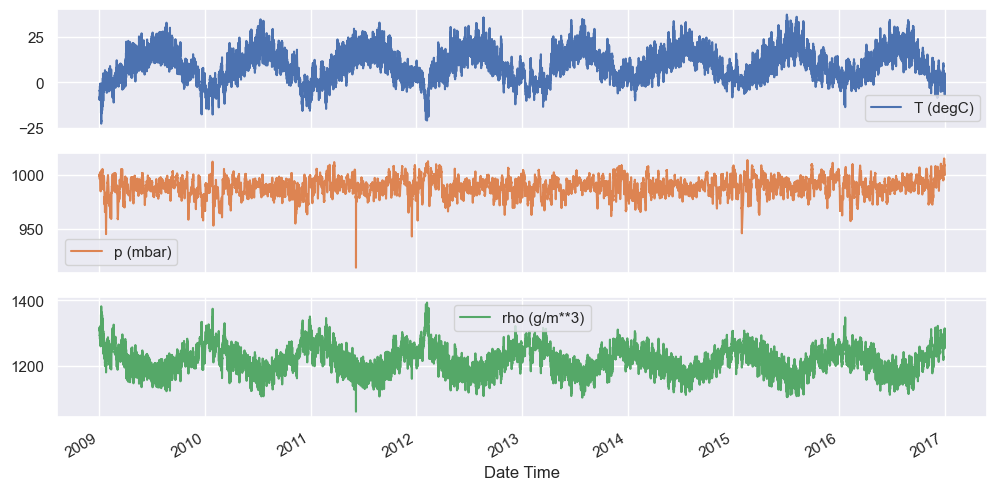

In [5]:
# Plot some variables
plot_cols = ["T (degC)", "p (mbar)", "rho (g/m**3)"]
plot_features = df[plot_cols]
plot_features.index = date_time
plot_features.plot(subplots=True, figsize=(12, 6))
plt.show()

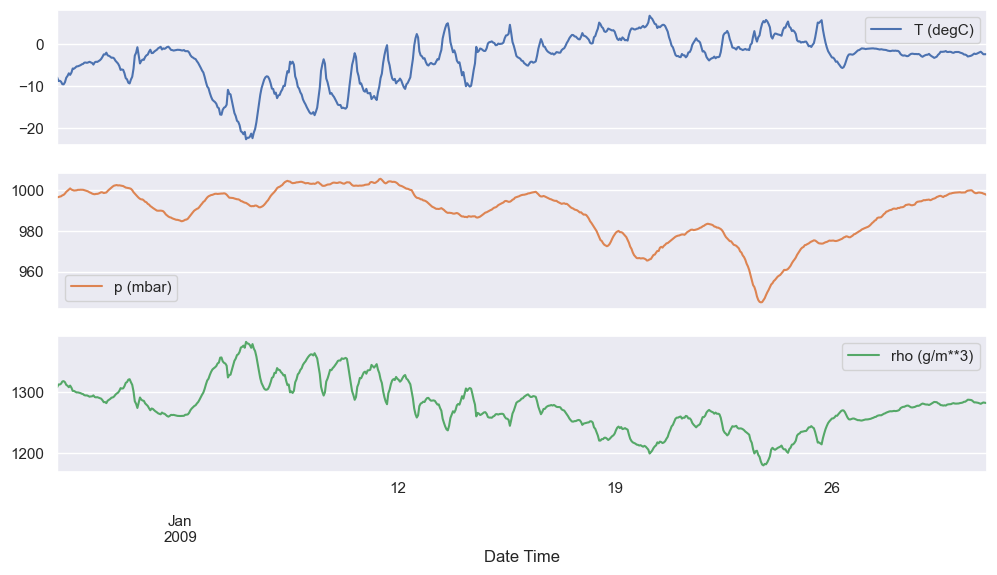

In [6]:
n_days = 30
plot_features = df[plot_cols][: 24*n_days]
plot_features.index = date_time[: 24*n_days]
plot_features.plot(subplots=True, figsize=(12, 6))
plt.show()

In [7]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
p (mbar),70091.0,989.212842,8.358886,913.60,984.20,989.57,994.720,1015.29
T (degC),70091.0,9.450482,8.423384,-22.76,3.35,9.41,15.480,37.28
Tpot (K),70091.0,283.493086,8.504424,250.85,277.44,283.46,289.530,311.21
Tdew (degC),70091.0,4.956471,6.730081,-24.80,0.24,5.21,10.080,23.06
rh (%),70091.0,76.009788,16.474920,13.88,65.21,79.30,89.400,100.00
VPmax (mbar),70091.0,13.576576,7.739883,0.97,7.77,11.82,17.610,63.77
VPact (mbar),70091.0,9.533968,4.183658,0.81,6.22,8.86,12.360,28.25
VPdef (mbar),70091.0,4.042536,4.898549,0.00,0.87,2.19,5.300,46.01
sh (g/kg),70091.0,6.022560,2.655812,0.51,3.92,5.59,7.800,18.07
H2OC (mmol/mol),70091.0,9.640437,4.234862,0.81,6.29,8.96,12.490,28.74


### Wind velocity transformation

One thing that should stand out is the min value of the wind velocity (wv (m/s)) and the maximum value (max. wv (m/s)) columns. This -9999 is likely erroneous.

There's a separate wind direction column, so the velocity should be greater than zero (>=0). Replace it with zeros:

In [8]:
# Replace outlier values by 0
wv = df["wv (m/s)"]
bad_wv = wv == -9999.0
wv[bad_wv] = 0.0

max_wv = df["max. wv (m/s)"]
bad_max_wv = max_wv == -9999.0
max_wv[bad_max_wv] = 0.0

Before diving in to build a model, it's important to understand the data and be sure that we're passing the model appropriately formatted data.

The column `wd (deg)` gives the wind direction in units of degrees. Angles do not make good model inputs: 360° and 0° should be close to each other and wrap around smoothly. Direction shouldn't matter if the wind is not blowing.

Right now the distribution of wind data looks as follows:

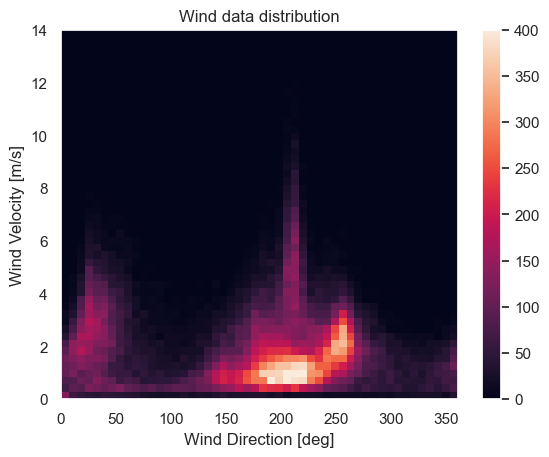

In [9]:
plt.hist2d(df["wd (deg)"], df["wv (m/s)"], bins=(50, 50), vmax=400)
plt.colorbar()
plt.xlabel("Wind Direction [deg]")
plt.ylabel("Wind Velocity [m/s]")
plt.title("Wind data distribution")
plt.show()

We will convert the wind direction and velocity columns to a wind vector so the distribution of wind vectors is much simpler for the model to correctly interpret:

In [10]:
# Extract wind velocities
wv = df.pop("wv (m/s)")
max_wv = df.pop("max. wv (m/s)")

# Convert to radians.
wd_rad = df.pop("wd (deg)") * np.pi / 180

# Calculate the wind x and y components.
df["Wx"] = wv * np.cos(wd_rad)
df["Wy"] = wv * np.sin(wd_rad)

# Calculate the max wind x and y components.
df["max Wx"] = max_wv * np.cos(wd_rad)
df["max Wy"] = max_wv * np.sin(wd_rad)

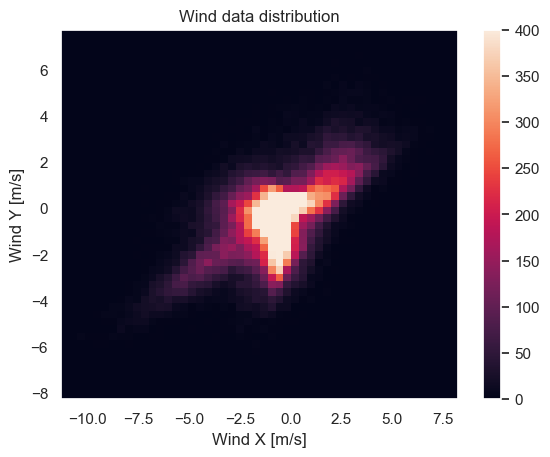

In [11]:
plt.hist2d(df["Wx"], df["Wy"], bins=(50, 50), vmax=400)
plt.colorbar()
plt.xlabel("Wind X [m/s]")
plt.ylabel("Wind Y [m/s]")
plt.title("Wind data distribution")
plt.show()

### Feature engineering

By inspecting some time series plots we can see that some weather data has daily and yearly periodicity. To check the assumptions, we use the tf.signal.rfft of the temperature over time.

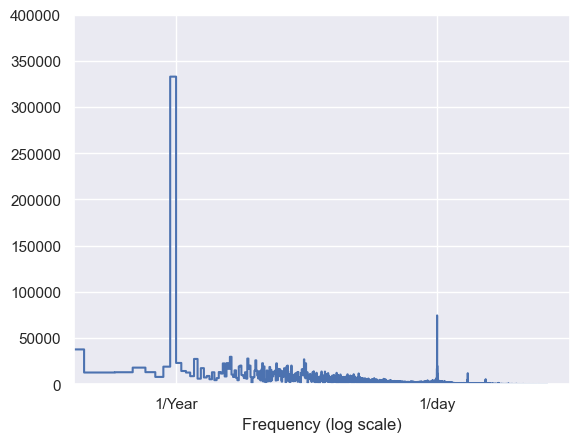

In [12]:
# Transform date_time to seconds
timestamp_s = date_time.map(pd.Timestamp.timestamp)

# Compute the real valued fft
fft = tf.signal.rfft(df["T (degC)"])
f_per_dataset = np.arange(0, len(fft))  # Frequency bins index

n_samples_h = len(df["T (degC)"])
hours_per_year = 24*365.2524
years_per_dataset = n_samples_h/(hours_per_year)

f_per_year = f_per_dataset / years_per_dataset
plt.step(f_per_year, np.abs(fft))
plt.xscale("log")
plt.ylim(0, 400000)
plt.xlim([0.1, max(plt.xlim())])
plt.xticks([1, 365.2524], labels=["1/Year", "1/day"])
plt.xlabel("Frequency (log scale)")
plt.show()

Them we can generate usable series by using sine and cosine transforms to create "Time of day" and "Time of year" signals. This gives the model access to the most important frequency features.

In [13]:
day = 24*60*60
year = (365.2425)*day

df["Day sin"] = np.sin(timestamp_s * (2 * np.pi / day))
df["Day cos"] = np.cos(timestamp_s * (2 * np.pi / day))
df["Year sin"] = np.sin(timestamp_s * (2 * np.pi / year))
df["Year cos"] = np.cos(timestamp_s * (2 * np.pi / year))

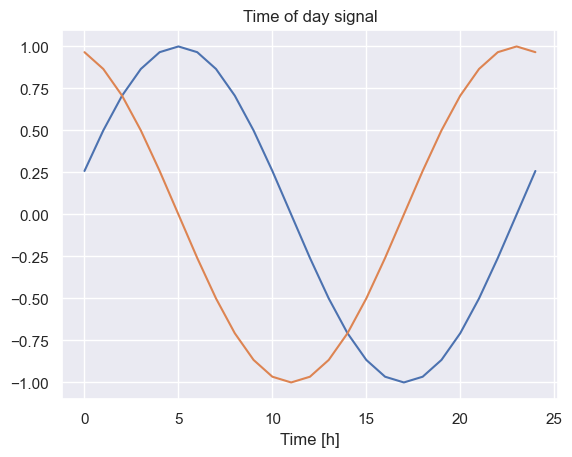

In [14]:
plt.plot(np.array(df["Day sin"])[:25])
plt.plot(np.array(df["Day cos"])[:25])
plt.xlabel("Time [h]")
plt.title("Time of day signal")
plt.show()

## Normalize the data

It is important to scale features before training a neural network. Normalization is a common way of doing this scaling. This is achieved by subtractiong the mean and divide by the standard deviation of each feature.

The mean and standard deviation should only be computed using the training data so that the models have no access to the values in the validation and test sets. This ensures that the model remains unaware of the validation and test sets. Here’s why this is important:

1. **Avoid Data Leakage**: Data leakage occurs when information from outside the training dataset is used to create the model. This can lead to overly optimistic performance estimates and poor generalization to unseen data. If the mean and standard deviation are computed using the entire dataset (including validation and test sets), information from the validation and test sets can "leak" into the training process, thereby contaminating the evaluation.

2. **Simulating Real-World Scenarios**: In a real-world scenario, new data points (i.e., validation and test data) will not be known in advance. By standardizing the data using only the training set statistics, we simulate the process of making predictions on new, unseen data more accurately.

3. **Ensuring Proper Model Evaluation**: The validation and test sets should serve as proxies for new data the model will encounter in production. If these sets are used in the standardization process, the model's evaluation metrics will not accurately reflect its performance on truly unseen data. This could lead to incorrect conclusions about the model's effectiveness and generalizability.

4. **Consistency**: The process ensures that the training, validation, and test sets are handled consistently. The model's parameters are determined based only on the training data, and the same transformation is applied to the validation and test data, ensuring consistency in preprocessing steps across different data splits.

It's also arguable that the model shouldn't have access to future values in the training set when training, and that this normalization should be done using moving averages. That's not the focus of this tutorial, and the validation and test sets ensure that we get (somewhat) honest metrics. So, in the interest of simplicity this tutorial uses a simple average.

### Split the data

We will use a ´(70%, 20%, 10%)´ split for the training, validation, and test sets respectively. Note the data is not being randomly shuffled before splitting. This is for two reasons:

1. It ensures that chopping the data into windows of consecutive samples is still possible.
2. It ensures that the validation/test results are more realistic, being evaluated on the data collected after the model was trained.

In [15]:
column_indices = {name: i for i, name in enumerate(df.columns)}

n = len(df)
train_df = df[0: int(n * 0.7)]
val_df = df[int(n * 0.7): int(n * 0.9)]
test_df = df[int(n * 0.9):]

num_features = df.shape[1]

In [16]:
# Normalize
train_mean = train_df.mean()
train_std = train_df.std()

train_df = (train_df - train_mean) / train_std
val_df = (val_df - train_mean) / train_std
test_df = (test_df - train_mean) / train_std

Now, peek at the distribution of the features. Some features do have long tails, but there are no obvious errors like the -9999 wind velocity value.

In [17]:
df_std = (df - train_mean) / train_std
df_std = df_std.melt(var_name="Column", value_name="Normalized")

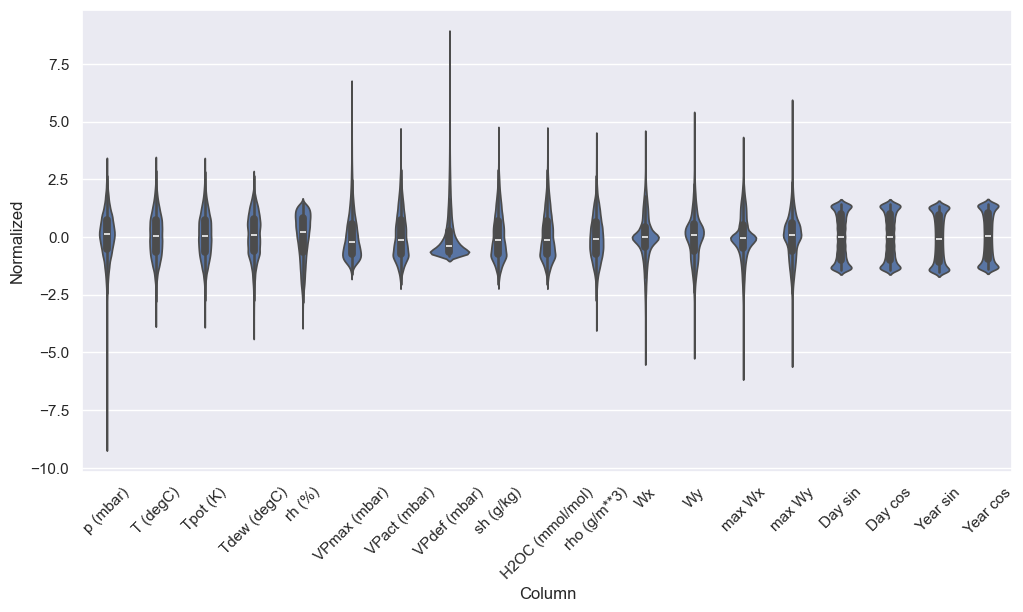

In [18]:
plt.figure(figsize=(12, 6))
ax = sns.violinplot(x="Column", y="Normalized", data=df_std)
ax.set_xticks(df_std["Column"].unique())  # Set the ticks
ax.set_xticklabels(df_std["Column"].unique(), rotation=45)  # Set the tick labels
plt.show()  

## Save preprocessed data

In [19]:
data = [
    train_df,
    val_df,
    test_df,
]

file_name = path.data_processed_dir("jena_climate_2009_2016_processed.dat")
open_file = open(file_name, "wb")
pickle.dump(data, open_file)
open_file.close()